In [18]:
import os
import cv2
import numpy as np
import shutil


input_folder = "/kaggle/input/img-colorize"  
output_folder = "/kaggle/working/processed_images"
test_folder = os.path.join(output_folder, "test_grayscale")
train_folder = os.path.join(output_folder, "train_lab")
os.makedirs(test_folder, exist_ok=True)
os.makedirs(train_folder, exist_ok=True)

In [19]:
def is_grayscale(image_path):

    image = cv2.imread(image_path)
    if len(image.shape) < 3 or image.shape[2] == 1:
        return True
    else:
        b, g, r = cv2.split(image)
        if (b == g).all() and (b == r).all():
            return True
    return False
def resize_image(image, output_size=(32, 32)):

    return cv2.resize(image, output_size)


def convert_to_lab(image):

    return cv2.cvtColor(image, cv2.COLOR_BGR2LAB)

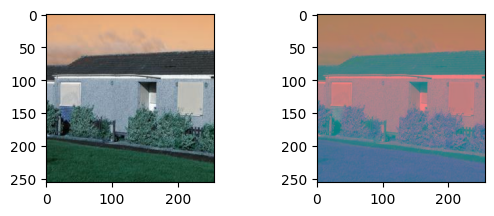

In [20]:
import cv2

img=cv2.imread("/kaggle/input/img-colorize/dataset/Train/00000503.jpg")

img1=convert_to_lab(img)
plt.subplot(2,2,1)
plt.imshow(img)
plt.subplot(2,2,2)
plt.imshow(img1)

Epoch 1/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 0.3805 - val_loss: 0.0682 - learning_rate: 0.0010
Epoch 2/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0734 - val_loss: 0.0793 - learning_rate: 0.0010
Epoch 3/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0663 - val_loss: 0.0766 - learning_rate: 0.0010
Epoch 4/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0660 - val_loss: 0.0668 - learning_rate: 0.0010
Epoch 5/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0645 - val_loss: 0.0687 - learning_rate: 0.0010
Epoch 6/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0651 - val_loss: 0.0667 - learning_rate: 0.0010
Epoch 7/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0648 - val_loss: 0.0665 - learning_rate: 0.0010
Epoch 8/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0641 - val_loss: 0.0666 - learning_rate: 0.0010
Epoch 9/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0645 - val_loss: 0.0665 - learning_rate: 0.0010

<ipython-input-21-af7e64f83326>:120: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 432 negative Z values that have been clipped to zero
  return lab2rgb(lab_image)
<ipython-input-21-af7e64f83326>:120: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 43 negative Z values that have been clipped to zero
  return lab2rgb(lab_image)
<ipython-input-21-af7e64f83326>:120: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 58 negative Z values that have been clipped to zero
  return lab2rgb(lab_image)
<ipython-input-21-af7e64f83326>:120: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 465 negative Z values that have been clipped to zero
  return lab2rgb(lab_image)
<ipython-input-21-af7e64f83326>:120: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 379 negative Z values that have been clipped to zero
  return lab2rgb(lab_image)


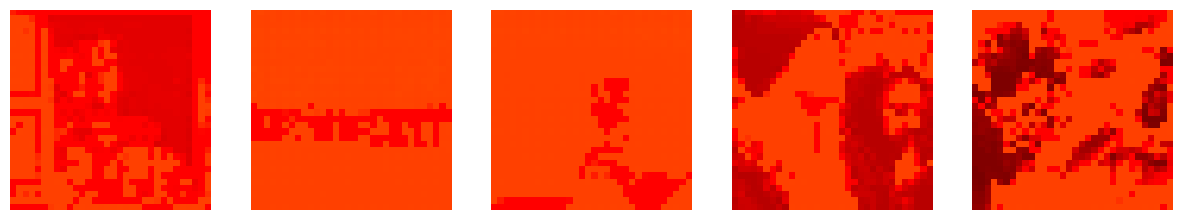

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from skimage.color import lab2rgb
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
from sklearn.model_selection import train_test_split


def load_and_preprocess_images(folder, image_size=(32, 32)):
    images, labels = [], []
    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        img = cv2.imread(img_path)
        if img is None or img.shape[0] == 0 or img.shape[1] == 0:
            continue  
        
        if len(img.shape) == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        
        img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        img = cv2.resize(img, image_size)
        
        l_channel, a_channel, b_channel = cv2.split(img)
        
        images.append(l_channel / 100.0)
        labels.append(np.stack([a_channel, b_channel], axis=-1) / 128.0)

    images = np.array(images).reshape(-1, image_size[0], image_size[1], 1)
    labels = np.array(labels)
    return images, labels


def build_colorization_model(input_shape=(32, 32, 1)):
    inputs = keras.Input(shape=input_shape)

    # Encoder
    x = layers.Conv2D(64, (3, 3), strides=2, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, (3, 3), strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(512, (3, 3), strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # Decoder
    x = layers.Conv2DTranspose(256, (3, 3), strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2DTranspose(128, (3, 3), strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2DTranspose(64, (3, 3), strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    outputs = layers.Conv2DTranspose(2, (3, 3), strides=2, padding='same', activation='tanh')(x)

    model = keras.Model(inputs, outputs)
    return model


train_folder = '/kaggle/input/img-colorize/dataset/Train'
test_folder = '/kaggle/input/img-colorize/dataset/Test'
train_data, train_labels = load_and_preprocess_images(train_folder)
test_data, test_labels = load_and_preprocess_images(test_folder)


train_data, val_data, train_labels, val_labels = train_test_split(
    train_data, train_labels, test_size=0.1, random_state=42)


model = build_colorization_model(input_shape=(32, 32, 1))
model.compile(optimizer=Adam(learning_rate=0.001), loss="mae")

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001)
]

history = model.fit(
    train_data, train_labels,
    batch_size=32,
    epochs=100,
    validation_data=(val_data, val_labels),
    callbacks=callbacks
)


def evaluate_model(model, test_data, test_labels):
    predictions = model.predict(test_data)
    
    
    psnr_scores = [psnr(test_labels[i], predictions[i], data_range=2) for i in range(len(test_data))]
    ssim_scores = [ssim(test_labels[i], predictions[i], channel_axis=-1, data_range=2) for i in range(len(test_data))]
    
    print(f"Average PSNR (AB channels): {np.mean(psnr_scores):.2f}")
    print(f"Average SSIM (AB channels): {np.mean(ssim_scores):.2f}")

evaluate_model(model, test_data, test_labels)


def show_results(model, test_data, num_samples=5):
    predictions = model.predict(test_data[:num_samples])
    
    plt.figure(figsize=(15, 5))
    for i in range(num_samples):
        colorized = reconstruct_colorized_image(test_data[i].squeeze(), predictions[i])
        plt.subplot(1, num_samples, i+1)
        plt.imshow(colorized)
        plt.axis('off')
    plt.show()

def reconstruct_colorized_image(l_channel, ab_pred):
    lab_image = np.zeros((*l_channel.shape, 3))
    lab_image[:,:,0] = np.clip(l_channel * 100, 0, 100)
    lab_image[:,:,1:] = np.clip(ab_pred * 128, -128, 128)
    return lab2rgb(lab_image)

show_results(model, test_data)

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np
import os
from glob import glob
from tqdm import tqdm
import matplotlib.pyplot as plt

In [30]:
# Dataset class
class ColorizationDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)  # Convert to LAB

        L = img[:, :, 0] / 255.0
        AB = img[:, :, 1:] / 128.0 - 1

        L = torch.tensor(L, dtype=torch.float32).unsqueeze(0)  # Add channel dim
        AB = torch.tensor(AB, dtype=torch.float32).permute(2, 0, 1)

        return L, AB

In [32]:
image_paths = glob("/kaggle/input/img-colorize/dataset/Train/*.jpg")  # Change this to your dataset path
dataset = ColorizationDataset(image_paths)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

In [33]:
class ColorizationCNN(nn.Module):
    def __init__(self):
        super(ColorizationCNN, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 2, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Tanh(),  # Normalize output to [-1,1] for AB channels
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Instantiate model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ColorizationCNN().to(device)

In [34]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [35]:
num_epochs = 20  # Adjust as needed

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for L, AB in tqdm(dataloader):
        L, AB = L.to(device), AB.to(device)

        optimizer.zero_grad()
        output = model(L)  # Predict AB channels

        loss = criterion(output, AB)  # Compute loss
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss / len(dataloader):.4f}")

torch.save(model.state_dict(), "colorization_model.pth")  # Save trained model

100%|██████████| 1041/1041 [01:00<00:00, 17.30it/s]


Epoch [1/20], Loss: 0.0104


100%|██████████| 1041/1041 [00:56<00:00, 18.40it/s]


Epoch [2/20], Loss: 0.0101


100%|██████████| 1041/1041 [00:56<00:00, 18.50it/s]


...

Epoch [18/20], Loss: 0.0096


100%|██████████| 1041/1041 [00:48<00:00, 21.27it/s]


Epoch [19/20], Loss: 0.0096


100%|██████████| 1041/1041 [00:49<00:00, 21.10it/s]


Epoch [20/20], Loss: 0.0096


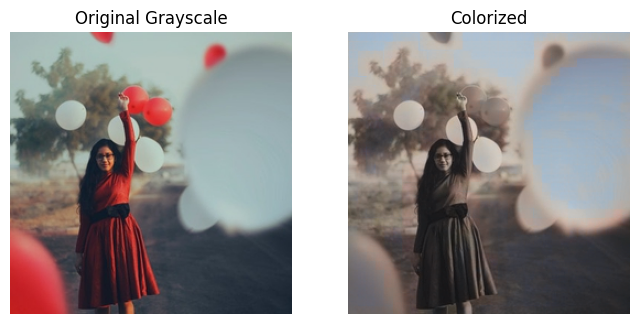

In [36]:
def predict_and_show(model, img_path):
    model.eval()
    img = cv2.imread(img_path)
    img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

    L = img_lab[:, :, 0] / 255.0  # Normalize L
    L_tensor = torch.tensor(L, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        ab_pred = model(L_tensor).cpu().squeeze(0)  # Get predicted AB channels

    ab_pred = ab_pred.numpy().transpose(1, 2, 0)
    ab_pred = (ab_pred + 1) * 128.0  # Denormalize to original range

    # Combine L with predicted AB
    img_colorized = np.concatenate([img_lab[:, :, 0:1], ab_pred], axis=-1)
    img_colorized = cv2.cvtColor(img_colorized.astype(np.uint8), cv2.COLOR_LAB2BGR)

    # Show result
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original Grayscale")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(img_colorized, cv2.COLOR_BGR2RGB))
    plt.title("Colorized")
    plt.axis("off")

    plt.show()

predict_and_show(model, "/kaggle/input/img-colorize/dataset/Train/03oZZu.jpg")